# **Блок 1. Выбор датасета**

## Был выбран данный в файле с домашним заданием

In [1816]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cosine
import pandas as pd
import time

df = pd.read_csv("ToyotaCorolla.csv")

# Блок 2. **Первичный анализ данных(EDA) и обработка**

## Информация о датасете

In [1817]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


## Первые 5 строчек датасета

In [1818]:
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


## Размеры датасета

In [1819]:
df.shape

(1436, 39)

## Проверка пустых ячеек

In [1820]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

## Пустых ячеек нет. Не нужно ничего дополнять

## Базовые статистики

In [1821]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Блок 3. Работа с признаками(Future Engineering)

## Кодирование категориальных параметров

In [1822]:
df_copy = df.copy()
df_copy = df_copy.drop(["Model"], axis = 1)
ohe_cols = ["Fuel_Type", "Color"]
df_copy = pd.get_dummies(df_copy, columns=ohe_cols, dtype="int")

## Параметр модель убираем, потому что он раскрывается через другие параметры(комплектующие)

## Строим таблицу корреляции, чтобы определить важные и менее важные параметры, но сначала проверим столбцы на уникальность данных

In [1823]:
df_copy.nunique()

Id                   1436
Price                 236
Age_08_04              77
Mfg_Month              12
Mfg_Year                7
KM                   1263
HP                     12
Met_Color               2
Automatic               2
CC                     13
Doors                   4
Cylinders               1
Gears                   4
Quarterly_Tax          13
Weight                 59
Mfr_Guarantee           2
BOVAG_Guarantee         2
Guarantee_Period        9
ABS                     2
Airbag_1                2
Airbag_2                2
Airco                   2
Automatic_airco         2
Boardcomputer           2
CD_Player               2
Central_Lock            2
Powered_Windows         2
Power_Steering          2
Radio                   2
Mistlamps               2
Sport_Model             2
Backseat_Divider        2
Metallic_Rim            2
Radio_cassette          2
Parking_Assistant       2
Tow_Bar                 2
Fuel_Type_CNG           2
Fuel_Type_Diesel        2
Fuel_Type_Pe

## Столбец "Cylinders" имеет 1 значение, значит его можно выкинуть, потому что он не будет иметь важности, ID также убирается по причине того, что от него цена не зависит

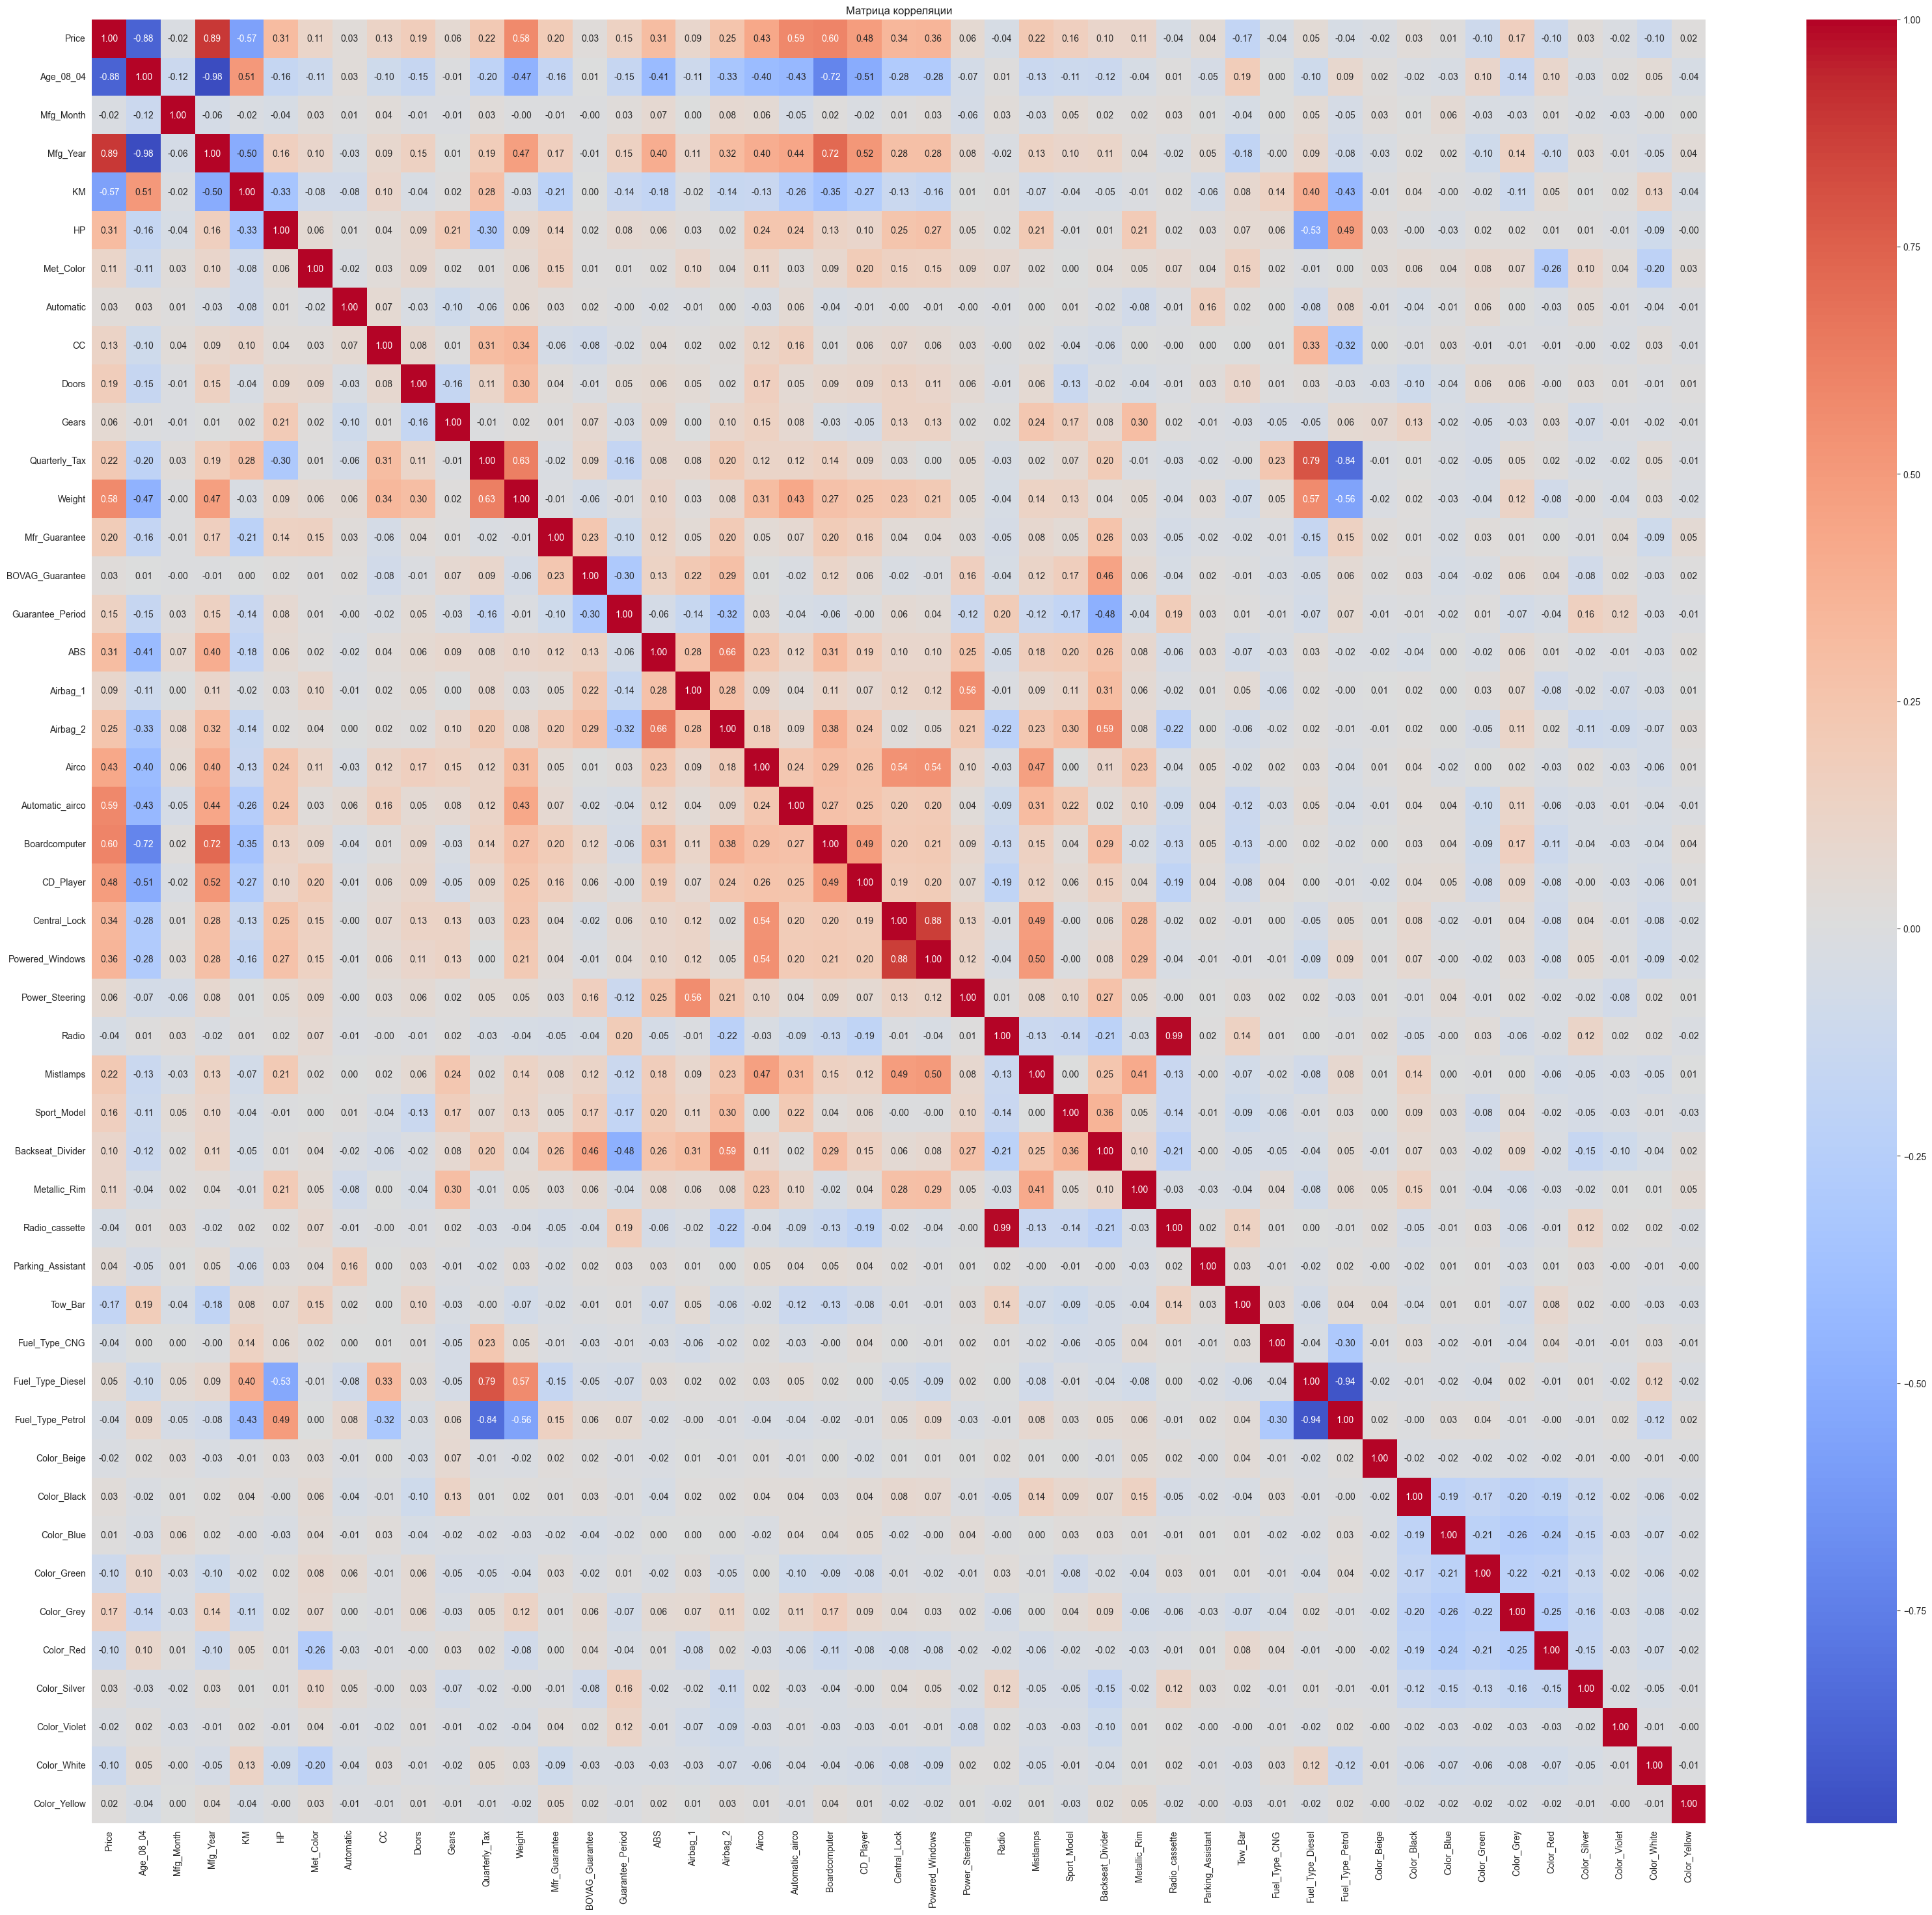

In [1824]:
df_copy = df_copy.drop(["Cylinders", "Id"], axis = 1)
plt.figure(figsize=(40, 36))
corr = df_copy.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляции")
plt.show()

## Параметры цвета показывают очень низкую связь с другими. Посмотрим ближе на связь всех параметров с ценой

In [1825]:
corr = df_copy.corr(numeric_only=True)["Price"].sort_values(ascending=False)
print(corr)

Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Color_Grey           0.169947
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Fuel_Type_Diesel     0.054084
Parking_Assistant    0.044375
Color_Black          0.034896
Automatic            0.033081
Color_Silver         0.028562
BOVAG_Guarantee      0.028133
Color_Yellow         0.022726
Color_Blue

## На этом моменте удалим все данные, которые имеют связь с ценой |x|< 0.4(сначала удаляли <0.12, но путем сравнения было выяснено, что < 0.4 лучше). Чтобы избавиться от малозначимых признаков

In [1826]:
corr_with_price = df_copy.corr(numeric_only=True)["Price"].sort_values(ascending=False)
low_corr_cols = corr_with_price[abs(corr_with_price) < 0.4 ].index
df_copy_filtered = df_copy.drop(columns=low_corr_cols)

## Не сложно догадаться, что "Age_08_04" и "Mfg_Year" выражаются друг через друга. Уберем один

In [1827]:
df_copy_filtered = df_copy_filtered.drop(["Age_08_04"], axis = 1)
df_copy_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Price            1436 non-null   int64
 1   Mfg_Year         1436 non-null   int64
 2   KM               1436 non-null   int64
 3   Weight           1436 non-null   int64
 4   Airco            1436 non-null   int64
 5   Automatic_airco  1436 non-null   int64
 6   Boardcomputer    1436 non-null   int64
 7   CD_Player        1436 non-null   int64
dtypes: int64(8)
memory usage: 89.9 KB


## Мы получили эти 7 параметров при которых была достигнута точность 0.874.

# **Блок 4. Разделение выборки**

In [1828]:
X_filtered = df_copy_filtered.drop("Price", axis = 1)
y_filtered =  df_copy_filtered["Price"]

X_filtered_train, X_filtered_test, y_filtered_train, y_filtered_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

## Данные были разделены на обучающую и тестовую выборки в соотношении 80/20. Это нужно для честной оценки качества модели на новых данных, поскольку проверка на тех же данных, на которых модель обучалась, не показывает реальную работоспособность.

## Проведем масштабирование. Для наших данных это особенно важно, потому что числа кратно отличаются

In [1829]:
scaler_filtered = StandardScaler()
X_filtered_train_scaled = scaler_filtered.fit_transform(X_filtered_train)
X_filtered_test_scaled = scaler_filtered.transform(X_filtered_test)

# **Блок 5. Обучение моделей(Linear regression, Ridge, Lasso)**

## Обучение Linear regression

In [1830]:
from sklearn.linear_model import LinearRegression

lr_filtered = LinearRegression()
lr_filtered.fit(X_filtered_train_scaled,y_filtered_train)
y_filtered_pred_train_lr = lr_filtered.predict(X_filtered_train_scaled)
y_filtered_pred_test_lr = lr_filtered.predict(X_filtered_test_scaled)

/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

## Обучение Ridge

Для Ridge и Lasso будем использовать разные alpha, чтобы найти лучшее alpha

In [1831]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

alphas = [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.01, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 10, 100, 200, 1000]

ridge = Ridge()

ridge_search = GridSearchCV(
    ridge,
    {"alpha": alphas},
    cv=5,
    scoring="neg_root_mean_squared_error"
)

ridge_search.fit(X_filtered_train_scaled, y_filtered_train)

print("Best alpha:", ridge_search.best_params_)

Best alpha: {'alpha': 10}


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

## Обучение Lasso

In [1832]:
from sklearn.linear_model import Lasso

lasso = Lasso()

lasso_search = GridSearchCV(
    lasso,
    {"alpha": alphas},
    cv=5,
    scoring="neg_root_mean_squared_error"
)

lasso_search.fit(X_filtered_train_scaled, y_filtered_train)

print("Best alpha:", lasso_search.best_params_)

/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

Best alpha: {'alpha': 2.5}


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

## Получено переполнение. Для этого проверим мультиколлинеарность, а после проверим наличие NaN и Inf

In [1833]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = pd.DataFrame(X_filtered_train_scaled, columns=X_filtered_train.columns)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

print("NaN in X_train_scaled:", np.isnan(X_filtered_train_scaled).sum())
print("Inf in X_train_scaled:", np.isinf(X_filtered_train_scaled).sum())
X_filtered_train.dtypes

           Feature       VIF
0         Mfg_Year  3.558582
5    Boardcomputer  2.240822
2           Weight  1.606260
1               KM  1.515305
6        CD_Player  1.457127
4  Automatic_airco  1.372229
3            Airco  1.227490
NaN in X_train_scaled: 0
Inf in X_train_scaled: 0


Mfg_Year           int64
KM                 int64
Weight             int64
Airco              int64
Automatic_airco    int64
Boardcomputer      int64
CD_Player          int64
dtype: object

## Причина переполнения не обнаружена:(

## Путем удаления некоторых параметров мы смогли снизить количество предупреждений, однако они все еще остались, проверим нашу модель и узнаем, насколько сильно это повлияет

## Обучение Ridge и Lasso с разными коэффициентами показало, что для Ridge подходит альфа 10, а для Lasso 2.5. Их и оставим

In [1834]:
ridge_filtered=Ridge(alpha = 10)
ridge_filtered.fit(X_filtered_train_scaled, y_filtered_train)
y_filtered_pred_train_ridge = ridge_filtered.predict(X_filtered_train_scaled)
y_filtered_pred_test_ridge = ridge_filtered.predict(X_filtered_test_scaled)

lasso_filtered=Lasso(alpha = 2.5)
lasso_filtered.fit(X_filtered_train_scaled, y_filtered_train)
y_filtered_pred_train_lasso = lasso_filtered.predict(X_filtered_train_scaled)
y_filtered_pred_test_lasso = lasso_filtered.predict(X_filtered_test_scaled)

/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

## Метрики

In [1835]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_train, y_train_pred, y_test, y_test_pred):

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_test = mean_absolute_error(y_test, y_test_pred)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    return rmse_train, rmse_test, mae_test, r2_train, r2_test

lr_metrics_filtered = evaluate(y_filtered_train, y_filtered_pred_train_lr, y_filtered_test, y_filtered_pred_test_lr)

ridge_metrics_filtered = evaluate(y_filtered_train, y_filtered_pred_train_ridge, y_filtered_test, y_filtered_pred_test_ridge)

lasso_metrics_filtered = evaluate(y_filtered_train, y_filtered_pred_train_lasso, y_filtered_test, y_filtered_pred_test_lasso)

## Таблица сравнения

In [1836]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression (filtered)",
        "Ridge (filtered)",
        "Lasso (filtered)"
    ],

    "RMSE Test": [
        lr_metrics_filtered[1],
        ridge_metrics_filtered[1],
        lasso_metrics_filtered[1]
    ],

    "MAE Test": [
        lr_metrics_filtered[2],
        ridge_metrics_filtered[2],
        lasso_metrics_filtered[2]
    ],

    "R2 Test": [
        lr_metrics_filtered[4],
        ridge_metrics_filtered[4],
        lasso_metrics_filtered[4]
    ]
})

results

,Model,RMSE Test,MAE Test,R2 Test
0,Linear Regression (filtered),1292.345546,889.649463,0.874827
1,Ridge (filtered),1290.199120,886.403638,0.875242
2,Lasso (filtered),1291.384104,888.865143,0.875013


In [1837]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

scores = cross_val_score(
    LinearRegression(),
    X_filtered_train_scaled,
    y_filtered_train,
    cv=5,
    scoring="r2"
)

print("CV R2:", scores)
print("Mean CV R2:", scores.mean())

CV R2: [0.87299665 0.90501781 0.89236006 0.87857502 0.86024604]
Mean CV R2: 0.8818391150082064


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

# Максимально был получен r2 = 0.874, а потом, проведя кросс-валидацию, средний вышел 0.882, однако я предлагаю провести еще несколько иследований, чтобы попытаться повысить r2

## Я хочу сделать два новых датасета с новыми параметрами. Первый: power_to_weight + options(там будет вся доп комплектация), второй: cc_to_weight + options. Из Age_08_04 и Mfg_Year мы оставим первое, либо все уберем. В дальнейшем я отказался от второй идеи, потому что она оказалась менее работоспособной

In [1838]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


In [1839]:
df_new_1 = df.copy()
df_new_2 = df.copy()
df_new_1 = df_new_1.drop(["Fuel_Type", "Color", "Cylinders", "Id"], axis = 1)
df_new_2 = df_new_2.drop(["Fuel_Type", "Model", "Color", "Cylinders", "Id"], axis = 1)

#Эти параметры мы удаляем, потому что ранее убедились, что они незначительны

options = ["Airco", "Automatic_airco", "ABS", "Airbag_1", "Airbag_2", "Central_Lock", "Powered_Windows", "Boardcomputer", "CD_Player", "Mistlamps", "Sport_Model", "Met_Color", "Automatic", "Mfr_Guarantee", "BOVAG_Guarantee", "Power_Steering", "Radio", "Backseat_Divider","Backseat_Divider", "Metallic_Rim", "Radio_cassette", "Parking_Assistant", "Tow_Bar"]



df_new_1["Power_to_weight"] = df_new_1["HP"] / df_new_1["Weight"]
df_new_1["Options"] = df_new_1[options].sum(axis=1)

# Внизу новые данные, которые были добавлены и сильно улучшили r2. Мы помогли показать модели, что год и км имеют не линейное влияние, а также что важны параметры km/time(показывает как часто использовалась машина), отношение веса и всяких плюшек со временем(их ценность падает). Был добавлен и параметр HP*age_08_04, но он снизил r2, а значит мы получили переобучение


df_new_1["Age_squared"] = df_new_1["Age_08_04"] ** 2
df_new_1["log_KM"] = np.log1p(df_new_1["KM"])
df_new_1["KM_per_year"] = df_new_1["KM"] / (df_new_1["Age_08_04"] + 1)
df_new_1["Weight_Age"] = df_new_1["Weight"] * df_new_1["Age_08_04"]
df_new_1["Options_Age"] = df_new_1["Options"] * df_new_1["Age_08_04"]
df_new_1 = df_new_1.drop(options, axis = 1)
df_new_1 = df_new_1.drop(["Mfg_Year", "CC"], axis = 1)
#Удаляем все виде |x| < 0.3 кроме добавленных
df_new_1 = df_new_1.drop(["Quarterly_Tax", "Doors", "Guarantee_Period", "Gears", "Mfg_Month"], axis = 1)
df_new_2["CC_to_weight"] = df_new_2["CC"] / df_new_2["Weight"]
df_new_2["Options"] = df_new_2[options].sum(axis=1)
df_new_2 = df_new_2.drop(options, axis = 1)
df_new_2 = df_new_2.drop(["Age_08_04", "HP"], axis = 1)
df_new_2 = df_new_2.drop(["Quarterly_Tax", "Doors", "Guarantee_Period", "Gears", "Mfg_Month"], axis = 1)

corr1 = df_new_1.corr(numeric_only=True)["Price"].sort_values(ascending=False)
print(corr1)

corr2 = df_new_2.corr(numeric_only=True)["Price"].sort_values(ascending=False)
print(corr2)

Price              1.000000
Weight             0.581198
Options            0.520062
HP                 0.314990
Power_to_weight    0.125487
KM_per_year       -0.050393
Options_Age       -0.465509
log_KM            -0.532554
KM                -0.569960
Age_squared       -0.811976
Weight_Age        -0.863892
Age_08_04         -0.876590
Name: Price, dtype: float64
Price           1.000000
Mfg_Year        0.885159
Weight          0.581198
Options         0.520062
CC              0.126389
CC_to_weight    0.022811
KM             -0.569960
Name: Price, dtype: float64


## По моим предположениям вторая модель будет слабее(предположение оказалось верным, поэтому потом я стал улучшать только первую)

## Разделение данных

In [1840]:
X_new_1 = df_new_1.drop("Price", axis = 1)
y_new_1 =  df_new_1["Price"]

X_new_1_train, X_new_1_test, y_new_1_train, y_new_1_test = train_test_split(
    X_new_1, y_new_1, test_size=0.2, random_state=42, shuffle=True
)

X_new_2 = df_new_2.drop("Price", axis = 1)
y_new_2 =  df_new_2["Price"]

X_new_2_train, X_new_2_test, y_new_2_train, y_new_2_test = train_test_split(
    X_new_2, y_new_2, test_size=0.2, random_state=42, shuffle = True
)

## Масштабирование + обработка параметра Model методом target encoding. Это мой один из самых противоречивых экспериментов. Он повысил r2, но он был сделан чтобы показать, что существует бизнес класс, средний и дешевые модели. Но чем больше был сглаживающий коэффициент, тем больше становился r2

In [1841]:
train_df_new_1 = X_new_1_train.copy()
train_df_new_1["Price"] = y_new_1_train

global_mean = y_new_1_train.mean()
model_stats = train_df_new_1.groupby("Model")["Price"].agg(["mean", "count"])
m = 1000

model_stats["Model_enc"] = (
    (model_stats["count"] * model_stats["mean"] + m * global_mean) /
    (model_stats["count"] + m)
)

model_map = model_stats["Model_enc"]

X_new_1_train["Model_enc"] = X_new_1_train["Model"].map(model_map)
X_new_1_test["Model_enc"] = X_new_1_test["Model"].map(model_map)

X_new_1_train["Model_enc"] = X_new_1_train["Model_enc"].fillna(global_mean)
X_new_1_test["Model_enc"] = X_new_1_test["Model_enc"].fillna(global_mean)

X_new_1_train = X_new_1_train.drop("Model", axis=1)
X_new_1_test = X_new_1_test.drop("Model", axis=1)

scaler_new_1 = StandardScaler()
X_new_1_train_scaled = scaler_new_1.fit_transform(X_new_1_train)
X_new_1_test_scaled = scaler_new_1.transform(X_new_1_test)

scaler_new_2 = StandardScaler()
X_new_2_train_scaled = scaler_new_2.fit_transform(X_new_2_train)
X_new_2_test_scaled = scaler_new_2.transform(X_new_2_test)

## Обучение моделей

## Linear Regression

In [1842]:
lr_new_1 = LinearRegression()
lr_new_1.fit(X_new_1_train_scaled,y_new_1_train)
y_new_1_pred_train_lr = lr_new_1.predict(X_new_1_train_scaled)
y_new_1_pred_test_lr = lr_new_1.predict(X_new_1_test_scaled)

lr_new_2 = LinearRegression()
lr_new_2.fit(X_new_2_train_scaled,y_new_2_train)
y_new_2_pred_train_lr = lr_new_2.predict(X_new_2_train_scaled)
y_new_2_pred_test_lr = lr_new_2.predict(X_new_2_test_scaled)


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

## Ищем коэффициенты для Ridge и Lasso

In [1843]:
ridge_search.fit(X_new_1_train_scaled, y_new_1_train)

print("Лучшее alpha для ridge_new_1:", ridge_search.best_params_)

lasso_search.fit(X_new_1_train_scaled, y_new_1_train)

print("Лучшее alpha для lasso_new_1:", lasso_search.best_params_)

ridge_search.fit(X_new_2_train_scaled, y_new_2_train)

print("Лучшее alpha для ridge_new_2:", ridge_search.best_params_)

lasso_search.fit(X_new_2_train_scaled, y_new_2_train)

print("Лучшее alpha для lasso_new_2:", lasso_search.best_params_)



/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered

Лучшее alpha для ridge_new_1: {'alpha': 0.01}


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.681e+08, tolerance: 1.225e+06
  model = cd_fast.enet_coordinate_descent(
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-pa

Лучшее alpha для lasso_new_1: {'alpha': 1e-05}
Лучшее alpha для ridge_new_2: {'alpha': 0.001}


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.006e+08, tolerance: 1.225e+06
  model = cd_fast.enet_coordinate_descent(
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-pa

Лучшее alpha для lasso_new_2: {'alpha': 1e-05}


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.682e+08, tolerance: 1.503e+06
  model = cd_fast.enet_coordinate_descent(


Получили для двух моделей 0.01 и 0.00001

In [1844]:
ridge_new_1=Ridge(alpha = 0.01)
ridge_new_1.fit(X_new_1_train_scaled, y_new_1_train)
y_new_1_pred_train_ridge = ridge_new_1.predict(X_new_1_train_scaled)
y_new_1_pred_test_ridge = ridge_new_1.predict(X_new_1_test_scaled)

lasso_new_1=Lasso(alpha = 0.00001)
lasso_new_1.fit(X_new_1_train_scaled, y_new_1_train)
y_new_1_pred_train_lasso = lasso_new_1.predict(X_new_1_train_scaled)
y_new_1_pred_test_lasso = lasso_new_1.predict(X_new_1_test_scaled)

ridge_new_2=Ridge(alpha=0.001)
ridge_new_2.fit(X_new_2_train_scaled, y_new_2_train)
y_new_2_pred_train_ridge = ridge_new_2.predict(X_new_2_train_scaled)
y_new_2_pred_test_ridge = ridge_new_2.predict(X_new_2_test_scaled)

lasso_new_2=Lasso(alpha=0.00001)
lasso_new_2.fit(X_new_2_train_scaled, y_new_2_train)
y_new_2_pred_train_lasso = lasso_new_2.predict(X_new_2_train_scaled)
y_new_2_pred_test_lasso = lasso_new_2.predict(X_new_2_test_scaled)

/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered

## Метрики

In [1845]:
def evaluate(y_train, y_train_pred, y_test, y_test_pred):

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_test = mean_absolute_error(y_test, y_test_pred)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    return rmse_train, rmse_test, mae_test, r2_train, r2_test

lr_metrics_new_1 = evaluate(y_new_1_train, y_new_1_pred_train_lr, y_new_1_test, y_new_1_pred_test_lr)

ridge_metrics_new_1 = evaluate(y_new_1_train, y_new_1_pred_train_ridge, y_new_1_test, y_new_1_pred_test_ridge)

lasso_metrics_new_1 = evaluate(y_new_1_train, y_new_1_pred_train_lasso, y_new_1_test, y_new_1_pred_test_lasso)

lr_metrics_new_2 = evaluate(y_new_2_train, y_new_2_pred_train_lr, y_new_2_test, y_new_2_pred_test_lr)

ridge_metrics_new_2 = evaluate(y_new_2_train, y_new_2_pred_train_ridge, y_new_2_test, y_new_2_pred_test_ridge)

lasso_metrics_new_2 = evaluate(y_new_2_train, y_new_2_pred_train_lasso, y_new_2_test, y_new_2_pred_test_lasso)

results_new = pd.DataFrame({

    "Model": [
        "Linear Regression 1",
        "Ridge 1",
        "Lasso 1",
        "Linear Regression 2",
        "Ridge 2",
        "Lasso 2"
    ],

    "RMSE Test": [
        lr_metrics_new_1[1],
        ridge_metrics_new_1[1],
        lasso_metrics_new_1[1],
        lr_metrics_new_2[1],
        ridge_metrics_new_2[1],
        lasso_metrics_new_2[1]
    ],

    "MAE Test": [
        lr_metrics_new_1[2],
        ridge_metrics_new_1[2],
        lasso_metrics_new_1[2],
        lr_metrics_new_2[2],
        ridge_metrics_new_2[2],
        lasso_metrics_new_2[2]
    ],

    "R2 Test": [
        lr_metrics_new_1[4],
        ridge_metrics_new_1[4],
        lasso_metrics_new_1[4],
        lr_metrics_new_2[4],
        ridge_metrics_new_2[4],
        lasso_metrics_new_2[4]
    ],

    "R2 Train": [
        lr_metrics_new_1[3],
        ridge_metrics_new_1[3],
        lasso_metrics_new_1[3],
        lr_metrics_new_2[3],
        ridge_metrics_new_2[3],
        lasso_metrics_new_2[3]
    ]
})

print(results_new)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

X = df_new_1.drop(["Price", "Model"], axis=1)
y = df_new_1["Price"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print("Mean:", scores.mean())
print("Std CV R2:", scores.std())

                 Model    RMSE Test    MAE Test   R2 Test  R2 Train
0  Linear Regression 1  1026.599323  768.661396  0.921013  0.910033
1              Ridge 1  1026.821005  768.754774  0.920979  0.910032
2              Lasso 1  1027.834122  768.986642  0.920823  0.909956
3  Linear Regression 2  1354.609983  937.406755  0.862475  0.871609
4              Ridge 2  1354.707204  937.414807  0.862455  0.871609
5              Lasso 2  1376.575929  940.110269  0.857979  0.871178
[0.91842068 0.89652395 0.89446079 0.91219999 0.91086934]
Mean: 0.9064949500418227
Std CV R2: 0.00936106450449272


/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-p

## Мы получили результат при кросс-валидации чуть хуже, потому что он не учитывал "Model", а также обучался на других наборах данных, возможно нам повезло с 0.921, но все равно результат отличается не сильно

## Если наша цель максимальная точность, то линейная модель с набором данных [Weight, Options, HP,Power_to_weight, KM_per_year, Options_Age, log_KM , KM, Age_squared, Weight_Age, Age_08_04]. R2 - 0.921, r2 mean - 0.906. Если мы хотим упростить модель, то уберем KM, Options_Age и Model_enc(при чем я как раз не мог объяснить влияние параметра Model_enc:)  ), и получим R2 - 0.915 и r2 mean - 0.905(почти ничего не потеряли, но модель стала проще)

## Посмотрим как меняется цена

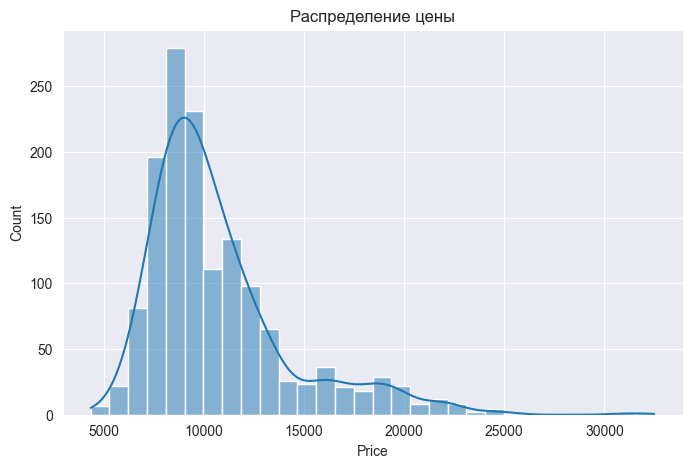

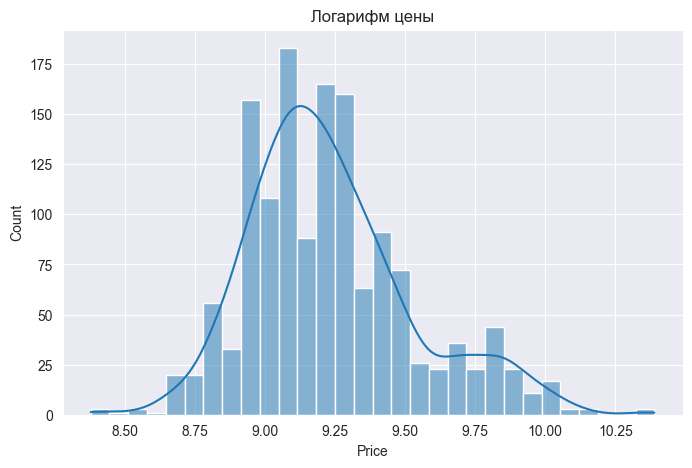

In [1846]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Распределение цены")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["Price"]), bins=30, kde=True)
plt.title("Логарифм цены")
plt.show()

## Попробуем обучить модель

In [1847]:
df_log = df_new_1.copy()
df_log["log_Price"] = np.log1p(df_log["Price"])
df_log = df_log.drop("Model", axis=1)

X = df_log.drop(["Price", "log_Price"], axis=1)
y_log = df_log["log_Price"]
y_true = df_log["Price"]

X_train, X_test, y_log_train, y_log_test, y_true_train, y_true_test = train_test_split(
    X, y_log, y_true, test_size=0.2, random_state=42, shuffle=True
)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_log_train)

y_log_pred = model.predict(X_test_scaled)

y_pred = np.expm1(y_log_pred)

rmse = np.sqrt(mean_squared_error(y_true_test, y_pred))
mae = mean_absolute_error(y_true_test, y_pred)
r2 = r2_score(y_true_test, y_pred)

results_log_no_model = pd.DataFrame({
    "Model": ["Linear Regression (log, no Model)"],
    "RMSE Test": [rmse],
    "MAE Test": [mae],
    "R2 Test": [r2]
})

results_log_no_model

/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Model,RMSE Test,MAE Test,R2 Test
0,"Linear Regression (log, no Model)",1071.516605,796.563115,0.91395


## Оказалось, что модель стала хуже. Все таки он стал понимать важность ошибки при маленькой цене, но и стал делать больше ошибки для машин с большой ценой

# Вывод

## 1. Какие метрики использовались и почему?
### Для сравнения моделей использовались следующие метрики: RMSE, MAE, R^2
### RMSE показывает среднюю ошибку модели с усиленным штрафом за большие отклонения. Используется, потому что в задаче оценки стоимости автомобиля важно сильнее наказывать большие ошибки
### MAE показывает среднюю абсолютную ошибку и более устойчив к выбросам. Используется как дополнительная метрика для понимания “средней” ошибки модели
### R^2 показывает долю объяснённой дисперсии целевой переменной. Позволяет оценить, насколько хорошо модель объясняет данные в целом и удобно сравнивать разные модели между собой
### Комбинация метрик позволяет оценить: точность (RMSE, MAE), общее качество модели (R^2)


## 2. На какой части выборки считались метрики?
### Метрики считались: на test-выборке — для финальной оценки качества модели; с помощью кросс-валидации (KFold, 5 фолдов) — для оценки устойчивости модели. Такой подход мне позволил: избежать зависимости от одного разбиения данных, получить более надёжную оценку качества модели

## 3. Какая модель справилась лучше?
### Лучшая модель — Linear Regression с расширенным набором признаков
### Результаты: R^2 Test +- 0.921, R^2 CV Mean +- 0.906
### Также была построена упрощённая версия модели (без части признаков), которая показала: R^2 Test +- 0.915, R^2 CV Mean +- 0.905
### Разница в качестве незначительная (-0.005–0.006), что позволяет выбрать более простую модель без существенной потери точности

## 4. Насколько хорошие получились результаты?
### Результаты можно считать очень хорошими, так как: модель объясняет около 92% вариации цены автомобилей,ошибки (RMSE и MAE) находятся на приемлемом уровне относительно масштаба цен, кросс-валидация показывает стабильные результаты (низкий разброс)
### Это говорит о том, что: модель хорошо улавливает зависимость цены от признаков, выбранные признаки информативны


## 5. Почему модель не переобучилась?
### Отсутствие переобучения подтверждается следующими фактами:
### 1. Сравнение Train и Test: R^2 Train +- 0.91, R^2 Test +- 0.92. Значения близки, а значит модель не запоминает данные
### 2. Кросс-валидация: Mean CV +- 0.905, Std +- 0.009 (низкий разброс). Модель показывает стабильные результаты на разных разбиениях
### 3. Поведение при удалении признаков: удаление части признаков почти не ухудшает качество, а значит модель не зависит критически от случайных факторов, а использует устойчивые закономерности


# Итог

### В ходе работы была построена стабильная и точная линейная модель, которая: показывает высокое качество (R^2 +- 0.92), устойчива к изменениям данных, не переобучается, может быть упрощена без значительной потери качества
### Наилучшим решением является выбор более простой модели, так как она обеспечивает баланс между точностью, интерпретируемостью и устойчивостью